#Assignment 09
#Using a Variational Autoencoder for Compression and Denoising

1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


2. Load MNIST Dataset

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images: 28x28 -> 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Testing data shape: (10000, 784)


3. Create VAE

In [3]:
class VAE(Model):
    def __init__(self, input_dim=784, latent_dim=2):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder_dense = layers.Dense(256, activation="relu")
        self.z_mean = layers.Dense(latent_dim)
        self.z_log_var = layers.Dense(latent_dim)

        # Decoder
        self.decoder_dense = layers.Dense(256, activation="relu")
        self.decoder_output = layers.Dense(input_dim, activation="sigmoid")

    def encode(self, x):
        h = self.encoder_dense(x)
        z_mean = self.z_mean(h)
        z_log_var = self.z_log_var(h)

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

        return z_mean, z_log_var, z

    def decode(self, z):
        h = self.decoder_dense(z)
        return self.decoder_output(h)

    def call(self, x):
        z_mean, z_log_var, z = self.encode(x)
        reconstruction = self.decode(z)

        # Reconstruction loss
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.square(x - reconstruction),
                axis=1
            )
        )

        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss

        self.add_loss(total_loss)

        return reconstruction

4. Train the VAE with Latent Dimension 2

In [4]:
latent_dim = 2

vae_2 = VAE(latent_dim=latent_dim)

vae_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
)

history_2 = vae_2.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 54.9025 - val_loss: 44.8653
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 43.9355 - val_loss: 43.0588
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 42.7880 - val_loss: 42.3391
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 42.1697 - val_loss: 41.8865
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 41.6680 - val_loss: 41.5221
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 41.2744 - val_loss: 41.0994
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 40.9465 - val_loss: 40.8181
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 40.6873 - val_loss: 40.6927
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 40.4170 - val_loss: 40.3763
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 40.1935 - val_loss: 40.1903
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 39.9932 - val_loss: 39.9587
Epoch 12/20
469/469

6. Compression Ratio

In [5]:
original_size = 784
latent_size = 2

compression_ratio_2 = original_size / latent_size

print("Original size:", original_size)
print("Latent size:", latent_size)
print("Compression ratio:", compression_ratio_2)

Original size: 784
Latent size: 2
Compression ratio: 392.0


7. Reconstruct 10 sample images

In [7]:
sample_images = x_test[:10]

reconstructed_images = vae_2.predict(sample_images)

mse_values = []

for i in range(10):
    mse = np.mean(
        np.square(sample_images[i] - reconstructed_images[i])
    )
    mse_values.append(mse)

for i, mse in enumerate(mse_values):
    print(f"Image {i+1}: MSE = {mse:.6f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Image 1: MSE = 0.030245
Image 2: MSE = 0.078877
Image 3: MSE = 0.006534
Image 4: MSE = 0.034846
Image 5: MSE = 0.032420
Image 6: MSE = 0.006967
Image 7: MSE = 0.056269
Image 8: MSE = 0.052709
Image 9: MSE = 0.091302
Image 10: MSE = 0.035654


8. Display Original v/s Reconstructed

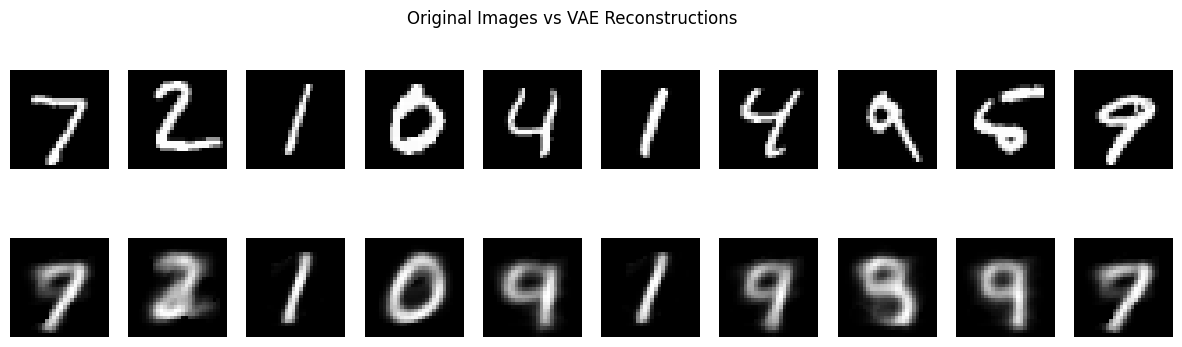

In [8]:
plt.figure(figsize=(15, 4))

for i in range(10):

    # Original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstruction
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original Images vs VAE Reconstructions")
plt.show()

9. Adding Gaussian Error

In [9]:
noise_factor = 0.3

noisy_images = sample_images + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=sample_images.shape
)

noisy_images = np.clip(noisy_images, 0.0, 1.0)

print("Noisy images created.")

Noisy images created.


In [10]:
#denoised images

denoised_images = vae_2.predict(noisy_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [12]:
denoising_mse = np.mean(
    np.square(sample_images - denoised_images)
)

noisy_mse = np.mean(
    np.square(sample_images - noisy_images)
)

print("Noisy Image MSE:", noisy_mse)
print("Denoised Image MSE:", denoising_mse)

Noisy Image MSE: 0.04511762184456718
Denoised Image MSE: 0.07646268


10. Compare clean, noisy and denoised images

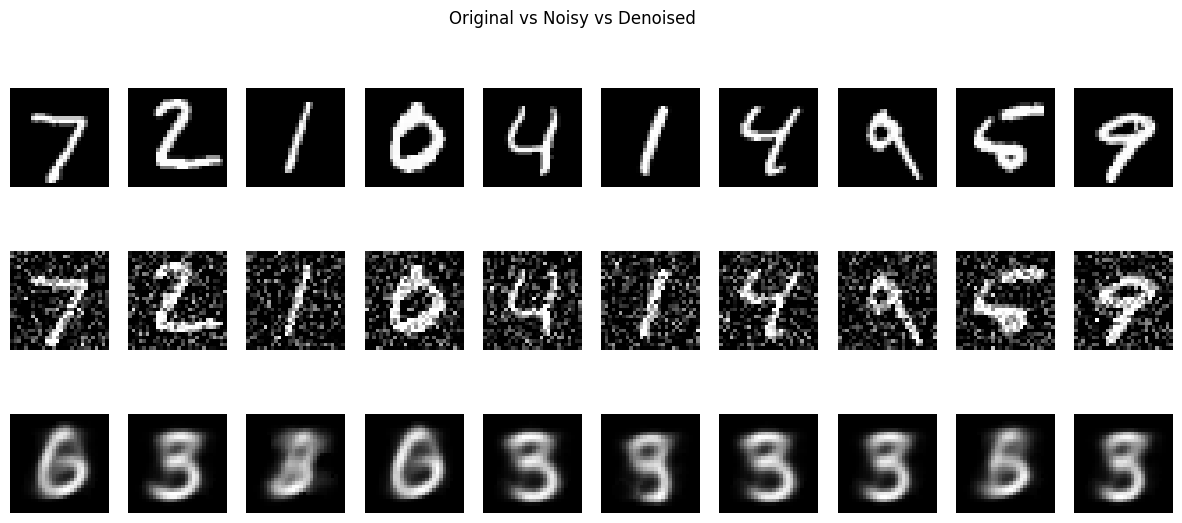

In [11]:

plt.figure(figsize=(15, 6))

for i in range(10):

    # Original
    plt.subplot(3, 10, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Noisy
    plt.subplot(3, 10, i + 11)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Denoised
    plt.subplot(3, 10, i + 21)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original vs Noisy vs Denoised")
plt.show()

11. function for LatenT dimension experiments

In [13]:
def train_vae(latent_dim, epochs=10):

    print(f"\nTraining VAE with latent dimension = {latent_dim}")

    vae = VAE(latent_dim=latent_dim)

    vae.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
    )

    history = vae.fit(
        x_train,
        x_train,
        epochs=epochs,
        batch_size=128,
        validation_data=(x_test, x_test),
        verbose=1
    )

    return vae, history

12. Train Latent Dimension 16 and LatenT Dimension 32

In [14]:

vae_16, history_16 = train_vae(
    latent_dim=16,
    epochs=10
)


Training VAE with latent dimension = 16
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 48.7684 - val_loss: 37.6753
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 35.9575 - val_loss: 34.4349
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 33.9557 - val_loss: 33.0693
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 32.9361 - val_loss: 32.2769
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 32.3316 - val_loss: 31.8331
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 31.9195 - val_loss: 31.4847
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 31.5983 - val_loss: 31.2543
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 31.3784 - val_loss: 31.0130
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 31.1990 - val_loss: 30.7770
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 31.0206 - val_loss: 30.6859


In [15]:
vae_32, history_32 = train_vae(
    latent_dim=32,
    epochs=10
)


Training VAE with latent dimension = 32
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 49.4531 - val_loss: 39.3275
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 37.4212 - val_loss: 35.5744
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 34.8128 - val_loss: 33.8500
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 33.5344 - val_loss: 32.7688
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 32.7961 - val_loss: 32.1861
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 32.2894 - val_loss: 31.7052
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 31.9073 - val_loss: 31.5942
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 31.6384 - val_loss: 31.2091
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 31.4400 - val_loss: 31.1168
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 31.2625 - val_loss: 31.0393


13. Calculate Compression Ratio

In [16]:
compression_2 = 784 / 2
compression_16 = 784 / 16
compression_32 = 784 / 32

print("Latent 2  :", compression_2, ":1")
print("Latent 16 :", compression_16, ":1")
print("Latent 32 :", compression_32, ":1")

Latent 2  : 392.0 :1
Latent 16 : 49.0 :1
Latent 32 : 24.5 :1


14. Calculate Reconstruction error of all three

In [17]:
def calculate_reconstruction_mse(vae, images):

    reconstructed = vae.predict(images, verbose=0)

    mse = np.mean(
        np.square(images - reconstructed)
    )

    return mse, reconstructed

In [18]:
mse_2, recon_2 = calculate_reconstruction_mse(
    vae_2, sample_images
)

mse_16, recon_16 = calculate_reconstruction_mse(
    vae_16, sample_images
)

mse_32, recon_32 = calculate_reconstruction_mse(
    vae_32, sample_images
)

print("Latent 2  MSE :", mse_2)
print("Latent 16 MSE :", mse_16)
print("Latent 32 MSE :", mse_32)

Latent 2  MSE : 0.042741783
Latent 16 MSE : 0.022886261
Latent 32 MSE : 0.024190918


15. Visual of Latent Dimensions

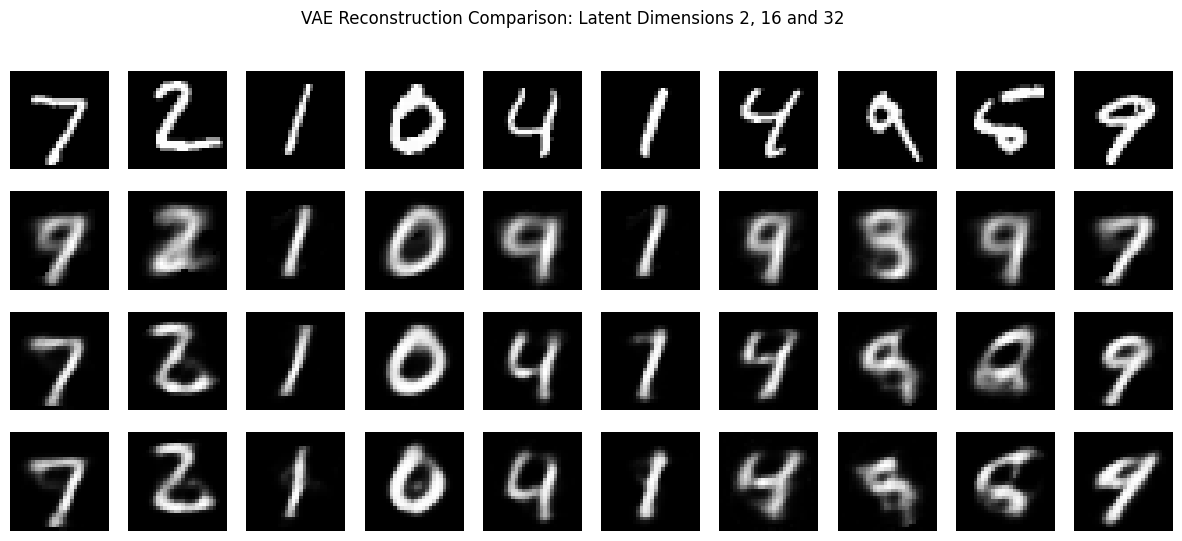

In [19]:
plt.figure(figsize=(15, 6))

for i in range(10):

    # Original
    plt.subplot(4, 10, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Latent 2
    plt.subplot(4, 10, i + 11)
    plt.imshow(recon_2[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Latent 16
    plt.subplot(4, 10, i + 21)
    plt.imshow(recon_16[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Latent 32
    plt.subplot(4, 10, i + 31)
    plt.imshow(recon_32[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle(
    "VAE Reconstruction Comparison: Latent Dimensions 2, 16 and 32"
)

plt.show()

16. Test Denoising for Latent 16 and 32

In [22]:
denoised_2 = vae_2.predict(noisy_images, verbose=0)
denoised_16 = vae_16.predict(noisy_images, verbose=0)
denoised_32 = vae_32.predict(noisy_images, verbose=0)

In [23]:
denoise_mse_2 = np.mean(
    np.square(sample_images - denoised_2)
)

denoise_mse_16 = np.mean(
    np.square(sample_images - denoised_16)
)

denoise_mse_32 = np.mean(
    np.square(sample_images - denoised_32)
)

print("Denoising MSE - Latent 2 :", denoise_mse_2)
print("Denoising MSE - Latent 16:", denoise_mse_16)
print("Denoising MSE - Latent 32:", denoise_mse_32)

Denoising MSE - Latent 2 : 0.076380685
Denoising MSE - Latent 16: 0.056346893
Denoising MSE - Latent 32: 0.053648986


#FINAL RESULT

ASSIGNMENT 9 - VAE COMPRESSION, RECONSTRUCTION AND DENOISING


,Latent Dimension,Compression Ratio,Reconstruction Error (MSE),Reconstruction Quality,Denoising Observation,Denoising MSE
0,2,392.0:1,0.043775,Moderate,Limited denoising improvement,0.074488
1,16,49.0:1,0.023749,Good,Limited denoising improvement,0.052412
2,32,24.5:1,0.022290,Good,Limited denoising improvement,0.053193


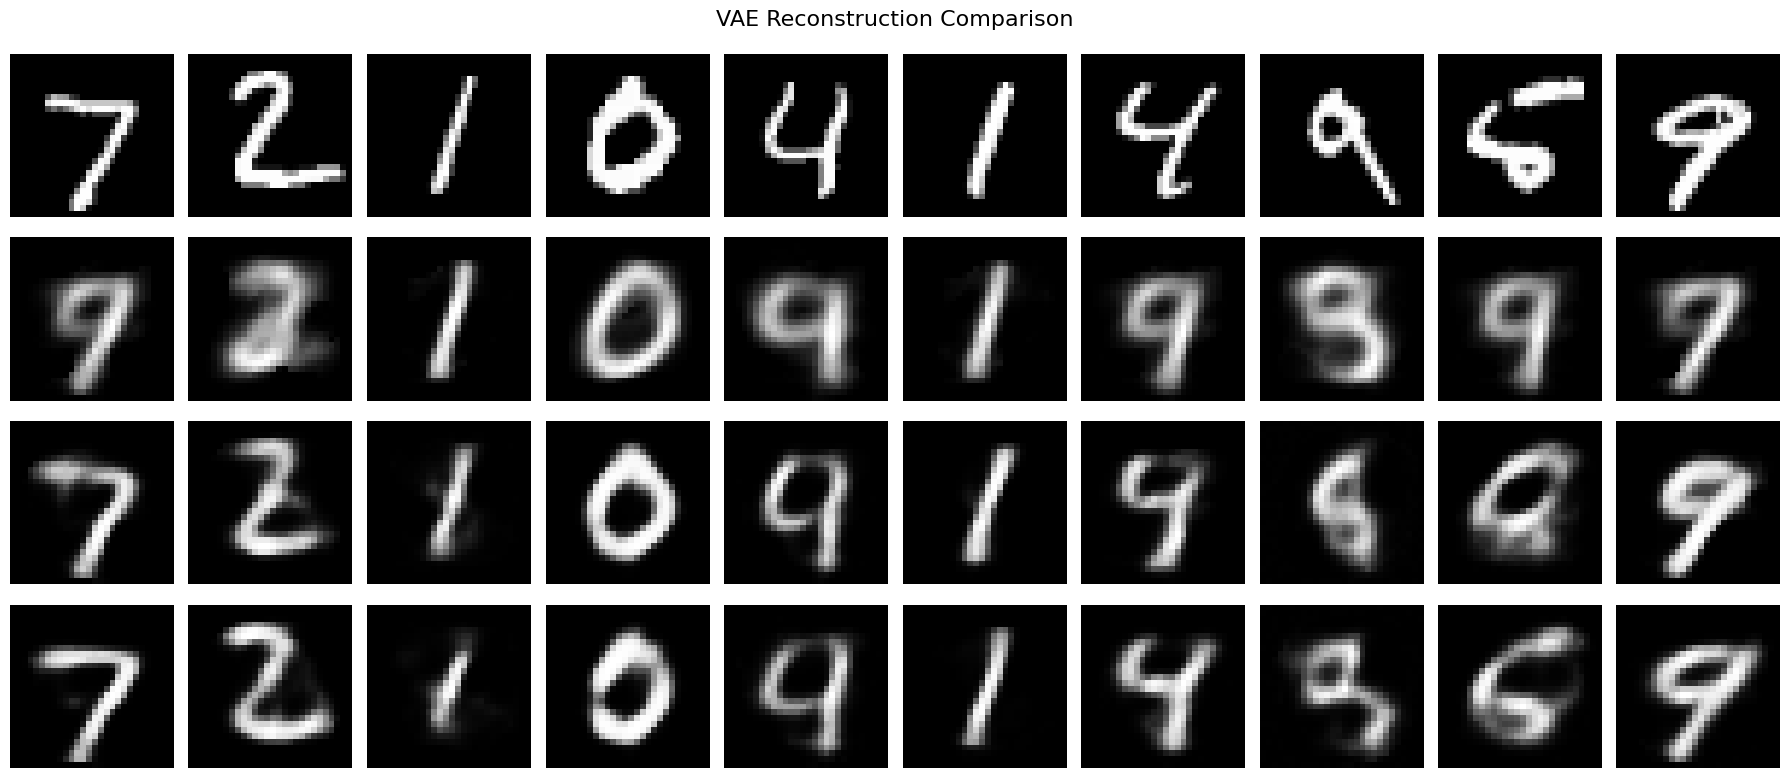

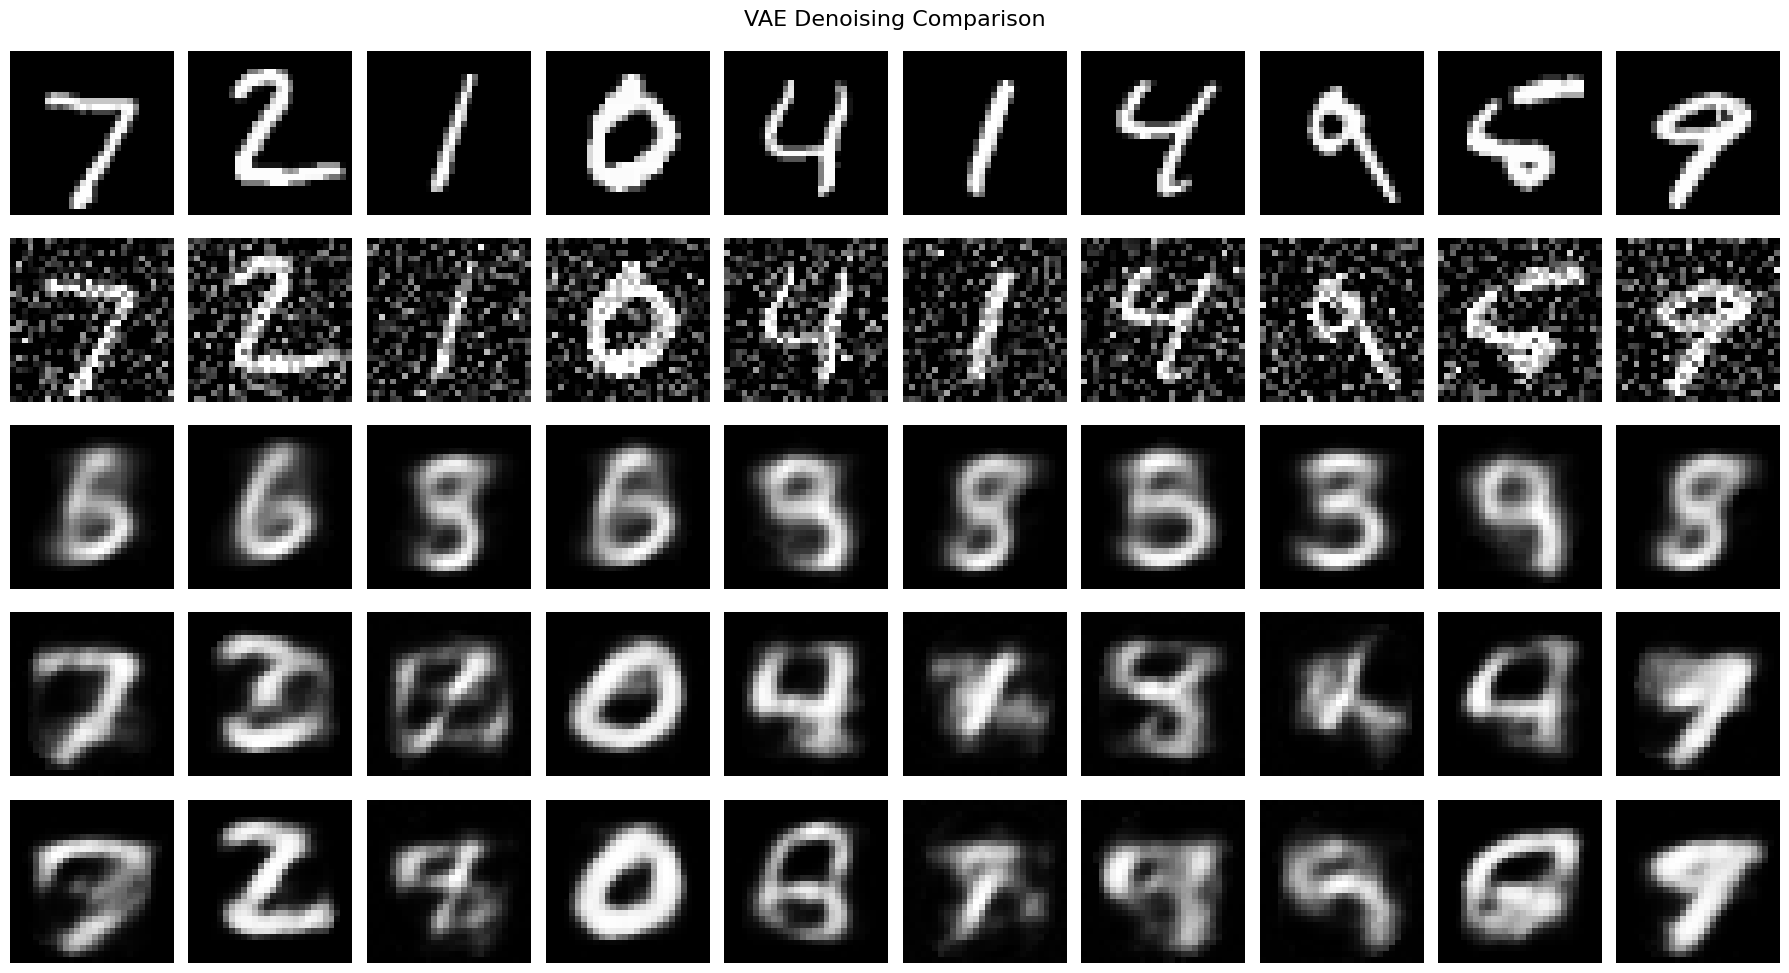


FINAL SUBMISSION SUMMARY
--------------------------------------------------
Latent Dimension : 2
Compression Ratio: 392.0:1
Reconstruction MSE: 0.043775
Quality           : Moderate
Denoising         : Limited denoising improvement
--------------------------------------------------
Latent Dimension : 16
Compression Ratio: 49.0:1
Reconstruction MSE: 0.023749
Quality           : Good
Denoising         : Limited denoising improvement
--------------------------------------------------
Latent Dimension : 32
Compression Ratio: 24.5:1
Reconstruction MSE: 0.022290
Quality           : Good
Denoising         : Limited denoising improvement
--------------------------------------------------


In [25]:

sample_images = x_test[:10]

# ------------------------------------------------------------
# 2. Add Gaussian noise
# ------------------------------------------------------------
noise_factor = 0.3

np.random.seed(42)

noisy_images = sample_images + noise_factor * np.random.normal(
    0, 1, sample_images.shape
)

noisy_images = np.clip(noisy_images, 0, 1)

# ------------------------------------------------------------
# 3. Function to evaluate each VAE
# ------------------------------------------------------------
def evaluate_vae(vae, latent_dim):

    # Reconstruction of clean images
    reconstructed = vae.predict(
        sample_images,
        verbose=0
    )

    # Reconstruction MSE
    reconstruction_mse = np.mean(
        np.square(sample_images - reconstructed)
    )

    # Denoising
    denoised = vae.predict(
        noisy_images,
        verbose=0
    )

    # MSE of noisy images against original
    noisy_mse = np.mean(
        np.square(sample_images - noisy_images)
    )

    # MSE of denoised images against original
    denoised_mse = np.mean(
        np.square(sample_images - denoised)
    )

    # Compression ratio
    compression_ratio = 784 / latent_dim

    # Automatic quality description
    if reconstruction_mse < 0.015:
        quality = "Excellent"
    elif reconstruction_mse < 0.030:
        quality = "Good"
    elif reconstruction_mse < 0.050:
        quality = "Moderate"
    else:
        quality = "Low"

    # Automatic denoising observation
    if denoised_mse < noisy_mse:
        improvement = (
            (noisy_mse - denoised_mse) / noisy_mse
        ) * 100

        denoising_observation = (
            f"Noise reduced; MSE improved by {improvement:.1f}%"
        )
    else:
        denoising_observation = (
            "Limited denoising improvement"
        )

    return {
        "Latent Dimension": latent_dim,
        "Compression Ratio": f"{compression_ratio:.1f}:1",
        "Reconstruction Error (MSE)": reconstruction_mse,
        "Reconstruction Quality": quality,
        "Denoising Observation": denoising_observation,
        "Denoising MSE": denoised_mse
    }, reconstructed, denoised


# ------------------------------------------------------------
# 4. Evaluate latent dimensions 2, 16 and 32
# ------------------------------------------------------------

result_2, recon_2, denoise_2 = evaluate_vae(
    vae_2, 2
)

result_16, recon_16, denoise_16 = evaluate_vae(
    vae_16, 16
)

result_32, recon_32, denoise_32 = evaluate_vae(
    vae_32, 32
)

# ------------------------------------------------------------
# 5. Create final results table
# ------------------------------------------------------------

results_df = pd.DataFrame([
    result_2,
    result_16,
    result_32
])

# Round numerical values
results_df["Reconstruction Error (MSE)"] = (
    results_df["Reconstruction Error (MSE)"].round(6)
)

results_df["Denoising MSE"] = (
    results_df["Denoising MSE"].round(6)
)

print("=" * 90)
print("ASSIGNMENT 9 - VAE COMPRESSION, RECONSTRUCTION AND DENOISING")
print("=" * 90)

display(results_df)


# ============================================================
# 6. COMPARISON IMAGE 1
# Original vs Reconstruction
# ============================================================

fig, axes = plt.subplots(
    4, 10,
    figsize=(18, 8)
)

# Original
for i in range(10):
    axes[0, i].imshow(
        sample_images[i].reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

axes[0, 0].set_ylabel(
    "Original",
    fontsize=12
)

# Latent 2
for i in range(10):
    axes[1, i].imshow(
        recon_2[i].reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[1, 0].set_ylabel(
    "Latent = 2",
    fontsize=12
)

# Latent 16
for i in range(10):
    axes[2, i].imshow(
        recon_16[i].reshape(28, 28),
        cmap="gray"
    )
    axes[2, i].axis("off")

axes[2, 0].set_ylabel(
    "Latent = 16",
    fontsize=12
)

# Latent 32
for i in range(10):
    axes[3, i].imshow(
        recon_32[i].reshape(28, 28),
        cmap="gray"
    )
    axes[3, i].axis("off")

axes[3, 0].set_ylabel(
    "Latent = 32",
    fontsize=12
)

plt.suptitle(
    "VAE Reconstruction Comparison",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. COMPARISON IMAGE 2
# Original vs Noisy vs Denoised
# ============================================================

fig, axes = plt.subplots(
    5, 10,
    figsize=(18, 10)
)

# Original
for i in range(10):
    axes[0, i].imshow(
        sample_images[i].reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

axes[0, 0].set_ylabel(
    "Original",
    fontsize=11
)

# Noisy
for i in range(10):
    axes[1, i].imshow(
        noisy_images[i].reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[1, 0].set_ylabel(
    "Noisy",
    fontsize=11
)

# Denoised - Latent 2
for i in range(10):
    axes[2, i].imshow(
        denoise_2[i].reshape(28, 28),
        cmap="gray"
    )
    axes[2, i].axis("off")

axes[2, 0].set_ylabel(
    "Denoised (2)",
    fontsize=11
)

# Denoised - Latent 16
for i in range(10):
    axes[3, i].imshow(
        denoise_16[i].reshape(28, 28),
        cmap="gray"
    )
    axes[3, i].axis("off")

axes[3, 0].set_ylabel(
    "Denoised (16)",
    fontsize=11
)

# Denoised - Latent 32
for i in range(10):
    axes[4, i].imshow(
        denoise_32[i].reshape(28, 28),
        cmap="gray"
    )
    axes[4, i].axis("off")

axes[4, 0].set_ylabel(
    "Denoised (32)",
    fontsize=11
)

plt.suptitle(
    "VAE Denoising Comparison",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 8. Print final submission summary
# ============================================================

print("\nFINAL SUBMISSION SUMMARY")
print("-" * 50)

for _, row in results_df.iterrows():

    print(
        f"Latent Dimension : {row['Latent Dimension']}"
    )

    print(
        f"Compression Ratio: {row['Compression Ratio']}"
    )

    print(
        f"Reconstruction MSE: "
        f"{row['Reconstruction Error (MSE)']:.6f}"
    )

    print(
        f"Quality           : "
        f"{row['Reconstruction Quality']}"
    )

    print(
        f"Denoising         : "
        f"{row['Denoising Observation']}"
    )

    print("-" * 50)